first of all importing all the required libraries for this project

In [4]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import tensorflow as tf
from tensorflow import keras
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()


In [6]:
x_train.shape

(50000, 32, 32, 3)

In [7]:
def plot(index):
    plt.figure(figsize=(10,1))
    plt.imshow(x_train[index])

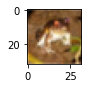

In [25]:
plot(0)

In [17]:
x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [9]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [11]:
y_train_categorical = keras.utils.to_categorical(y_train,
num_classes=10,dtype='float32'
)

In [13]:
y_test_categorical = keras.utils.to_categorical(y_test,
num_classes=10,dtype='float32'
)

In [24]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000 , activation= 'relu'),
    keras.layers.Dense(1000, activation='relu'),
    keras.layers.Dense(10,activation= 'sigmoid')
])
model.compile(optimizer='SGD',
            loss= 'categorical_crossentropy',
            metrics=['accuracy'])


model.fit(x_train_scaled,y_train_categorical,epochs=5)

1

In [23]:
np.argmax(model.predict(x_train_scaled)[1])

313/313 [==============================] - 16s 35ms/step - loss: 1.4925 - accuracy: 0.4654


[1.4924869537353516, 0.46540001034736633]

In [ ]:
model.evaluate(x_test_scaled,y_test_categorical)